In [11]:
!pip install -q flatbuffers
!pip install -q rdkit
!pip install -q tensorflow

In [14]:
import ast
import re
import numpy as np
import pandas as pd
from flatbuffers.packer import int32
from rdkit import Chem
import tensorflow as tf
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

ImportError: Traceback (most recent call last):
  File "c:\Anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [2]:
%run ../PyFiles/matrix_to_mol.py
%run ../PyFiles/preprocess.py
%run ../PyFiles/rewards.py
%run ../PyFiles/graph_generator_capstone.py
%run ../PyFiles/original_discriminator.py
%run ../PyFiles/hierarchical_discriminator.py
%run ../PyFiles/hierarchical_discriminator_nd.py
%run ../PyFiles/test_graph_gen.py

ModuleNotFoundError: No module named 'tensorflow'

ModuleNotFoundError: No module named 'tensorflow'

ModuleNotFoundError: No module named 'rdkit'

ModuleNotFoundError: No module named 'tensorflow'

ModuleNotFoundError: No module named 'tensorflow'

ModuleNotFoundError: No module named 'tensorflow'

ModuleNotFoundError: No module named 'tensorflow'

ModuleNotFoundError: No module named 'tensorflow'

In [5]:
#use in get_data.py
def normalize_graph_features(x):
    x = re.sub(r'(?<=[0-9])\s+(?=[0-9])', ',', x)
    x = re.sub(r'\]\s+\[', '],[', x)
    return x

In [6]:
qm9 = pd.read_csv("../Data/qm9.csv")
qm9.tail()

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom,Morgan_fingerprint,adj_matrix,node_features,node_count
133880,gdb_133881,C1C2C3C4C5OC14C5N23,3.59483,2.19899,1.90423,1.6637,69.37,-0.2254,0.0588,0.2842,...,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 0 1]\n [...,"[[6], [6], [6], [6], [6], [8], [6], [6], [7]]",9
133881,gdb_133882,C1N2C3C2C2C4OC12C34,3.65648,2.14237,1.90439,1.2976,69.52,-0.2393,0.0608,0.3002,...,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 0 1 0]\n [1 0 1 1 0 0 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [8], [6], [6]]",9
133882,gdb_133883,C1N2C3C4C5C2C13CN45,3.67118,2.14314,1.89501,1.2480,73.60,-0.2233,0.0720,0.2953,...,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 1 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [7]]",9
133883,gdb_133884,C1N2C3C4C5CC13C2C45,3.52845,2.15131,1.86582,1.9576,77.40,-0.2122,0.0881,0.3003,...,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [6]]",9
133884,gdb_133885,C1N2C3C4C5OC13C2C45,3.64015,2.21764,1.93793,0.8626,69.48,-0.2316,0.0742,0.3058,...,-400.662186,23.434,-1603.471865,-1614.455155,-1623.345075,-1492.247150,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [8], [6], [6], [6]]",9


In [7]:
#use in get_data.py
qm9['adj_matrix'] = qm9["adj_matrix"].apply(normalize_graph_features)
qm9['node_features'] = qm9["node_features"].apply(normalize_graph_features)

In [8]:
#use in get_data.py
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: np.array(ast.literal_eval(x)))
qm9['node_features'] = qm9['node_features'].apply(lambda x: ast.literal_eval(x))

In [9]:
valid_atom_types = [1, 6, 7, 8, 9]
num_features = len(valid_atom_types)

max_size = max(matrix.shape[0] for matrix in qm9['adj_matrix'])

one_hot_node_features = [
    preprocess_node_features(nf, valid_atom_types, num_nodes)
    for nf, num_nodes in zip(qm9['node_features'], qm9['node_count'])
]
one_hot_node_features = [
    pad_one_hot_features(features, max_size, num_features)
    for features in one_hot_node_features
]

In [11]:
node_features = tf.argmax(one_hot_node_features, axis = -1)
node_features = np.array(node_features)
node_counts = qm9['node_count']
adj_matrices_train = qm9['adj_matrix'][:1000]
sliced_features = []
train_smiles = []

for node_feature, node_count in zip(node_features, node_counts):
  sliced_features.append(node_feature[:node_count])

feature_map = {
    0 : valid_atom_types[0],
    1 : valid_atom_types[1],
    2 : valid_atom_types[2],
    3 : valid_atom_types[3],
    4 : valid_atom_types[4]
}
mapped_features = [0] * len(sliced_features)

for i in range(len(sliced_features)):
    mapped_features[i] = [feature_map[value] for value in sliced_features[i]]

node_features_small = mapped_features[:1000]

for i in range(len(adj_matrices_train)):
    train_smiles.append(Chem.MolToSmiles(adjacency_matrix_to_mol(adj_matrices_train[i], node_features_small[i])))

In [12]:
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: pad_adj_matrix(x, max_size))

In [13]:
adj_matrices = np.stack(qm9['adj_matrix'].values)
one_hot_node_features = np.stack(one_hot_node_features)

In [14]:
adj_matrices_small = adj_matrices[:1000]
one_hot_node_features_small = one_hot_node_features[:1000]
dataset_small = create_dataset(adj_matrices_small, one_hot_node_features_small, batch_size=32)

In [15]:
dataset = create_dataset(adj_matrices, one_hot_node_features, batch_size=32)

In [69]:
generator = GraphGenerator(num_nodes=max_size, node_features=num_features, latent_dim=512)
discriminator = GraphDiscriminatorNoDiff(num_nodes=max_size, node_features=num_features)

d_loss, g_loss, r_loss, scl_loss = generator.fit(dataset_small, discriminator, train_smiles, epochs=10)

[19:03:08] WARNING: not removing hydrogen atom without neighbors
[19:03:08] WARNING: not removing hydrogen atom without neighbors
[19:03:08] WARNING: not removing hydrogen atom without neighbors
[19:03:08] WARNING: not removing hydrogen atom without neighbors


Epoch 1/10 D Loss: 1.5307 G Loss: 0.5318 R Loss: 0.0000 Scaled Loss: 0.5318
Epoch 1/10 D Loss: 1.5290 G Loss: 0.5323 R Loss: -0.1650 Scaled Loss: -7.4476


[19:03:08] WARNING: not removing hydrogen atom without neighbors
[19:03:08] WARNING: not removing hydrogen atom without neighbors
[19:03:09] WARNING: not removing hydrogen atom without neighbors
[19:03:09] WARNING: not removing hydrogen atom without neighbors


Epoch 1/10 D Loss: 1.5274 G Loss: 0.5330 R Loss: -0.2459 Scaled Loss: -11.3570
Epoch 1/10 D Loss: 1.5281 G Loss: 0.5338 R Loss: -0.2929 Scaled Loss: -13.6314


[19:03:09] WARNING: not removing hydrogen atom without neighbors
[19:03:09] WARNING: not removing hydrogen atom without neighbors
[19:03:09] WARNING: not removing hydrogen atom without neighbors
[19:03:09] WARNING: not removing hydrogen atom without neighbors


...

[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:12] WARNING: not removing hydrogen atom without neighbors


Epoch 1/10 D Loss: 1.5080 G Loss: 0.5529 R Loss: -0.3647 Scaled Loss: -17.0951
Epoch 1/10 D Loss: 1.5073 G Loss: 0.5537 R Loss: -0.3622 Scaled Loss: -16.9694


[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:12] WARNING: not removing hydrogen atom without neighbors
2025-04-01 19:03:12.843943: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/10 D Loss: 1.5063 G Loss: 0.5545 R Loss: -0.3595 Scaled Loss: -16.8438
Epoch 1/10 D Loss: 1.5069 G Loss: 0.5552 R Loss: -0.3569 Scaled Loss: -16.7138


[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:12] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not removing hydrogen atom without neighbors
[19:03:13] WARNING: not r

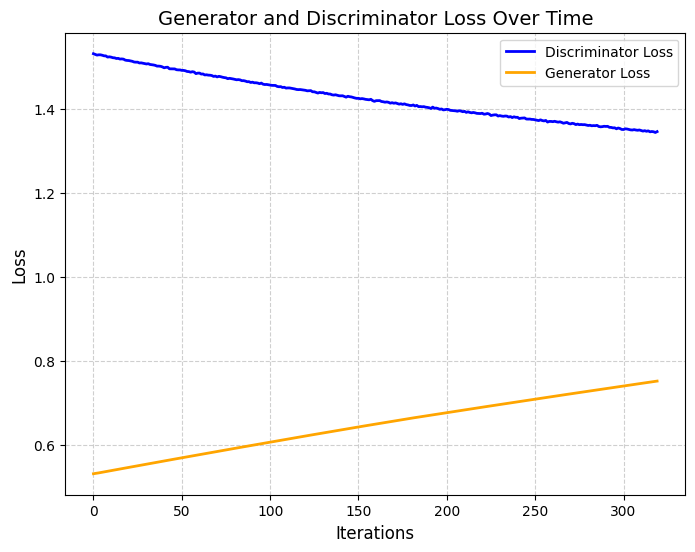

In [70]:
plt.figure(figsize=(8, 6)) 
plt.plot(d_loss, label = "Discriminator Loss", color = "blue", linewidth = 2)  
plt.plot(g_loss, label = "Generator Loss", color = "orange", linewidth = 2)  
#plt.plot(scl_loss, label = "Scaled Loss", color = "red", linewidth = 2)
#plt.plot(r_loss, label = "Reward Loss", color = "magenta", linewidth = 2)

plt.xlabel("Iterations", fontsize = 12)
plt.ylabel("Loss", fontsize = 12)
plt.title("Generator and Discriminator Loss Over Time", fontsize = 14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6) 

plt.show()

### Notes
    smoothing reduced the high generator loss and made the discriminator loss not go as low

    random flipping of the labels cuased the spikes in loss for the discriminator and made the generator stagnat and not go as high

In [71]:
z_sample = tf.random.normal((1, 512))
adj, nodes = generator(z_sample)

In [72]:
nodes

<tf.Tensor: shape=(1, 9, 5), dtype=float32, numpy=
array([[[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]], dtype=float32)>

[19:03:58] WARNING: not removing hydrogen atom without neighbors
[19:03:58] WARNING: not removing hydrogen atom without neighbors


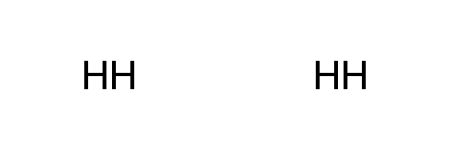

In [73]:
mol = adjacency_matrix_to_mol(adj, nodes)
mol = Chem.RemoveHs(mol)
mol